### Import Libraries

In [364]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML


import time
import urllib, requests, json
import random, math

import re
import string


import spacy
import en_core_web_trf
from spacy.lang.en.examples import sentences 
from spacy.language import Language
import spacy_transformers

import nltk
from nltk.tokenize import (sent_tokenize, word_tokenize)
from nltk.tokenize import RegexpTokenizer
from nltk.tokenize import regexp_tokenize
from nltk.corpus import stopwords

#Stemmer
from nltk.stem import PorterStemmer
from nltk.stem import SnowballStemmer
from nltk.stem import LancasterStemmer
from nltk.stem import RegexpStemmer

#Lemmatizer
from nltk.stem import WordNetLemmatizer

In [365]:
#Description:
#I took the one of the most popular esport events in CS discipline - PGL Major Stockholm 2021
#https://escharts.com/tournaments/csgo/pgl-major-stockholm-2021

# Primary goal
# Understand the sentiment of audience

### Import files

In [367]:
df = pd.read_csv('/Users/rodionhorbunov/Downloads/df.csv')
df_local_emotes = pd.read_csv('/Users/rodionhorbunov/Downloads/Emotes.csv')

/var/folders/v0/fxrw_pj55h31gf_c707bpsw80000gn/T/ipykernel_1688/2980275568.py:1: DtypeWarning: Columns (4,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/rodionhorbunov/Downloads/df.csv')


In [368]:
global_twitch_emotes = ['OMEGALUL','Pog','PepeHands','widepeepoHappy','Pepega','LULW','KEKW','monkaW','5Head','POGGERS','AYAYA','PepeLaugh','widepeepoSad','Sadge','FeelsBadMan','HYPERS','YEP','FeelsOkayMan','Kapp','EZY','HandsUp','3Head','PepoThink','gachiGASM','FeelsWeirdMan','monkaHmm','forsenCD','KKomrade','PepoG','monkaGun','monkaOMEGA','peepoBlanket','monkaEyes','peepoHappy','FeelsStrongMan','HYPERBRUH','monkaTOS','peepoLove','FeelsGoodMan','weSmart','KKonaW','FeelsDankMan','4HEad','REEeee','monkaH','WideHardo','FeelsSpecialMan','PepeLaugh','KEKWait','Kappa','4Head','ANELE','ArgieB8','ArsonNoSexy','AsexualPride','AsianGlow','B)','B-)','BCWarrior','BOP','BabyRage','BatChest','BegWan','BibleThump','BigBrother','BigPhish','BisexualPride','BlackLivesMatter','BlargNaut','BloodTrail','BrainSlug','BrokeBack','BuddhaBar','CaitlynS','CarlSmile','ChefFrank','CoolCat','CoolStoryBob','CorgiDerp','CrreamAwk','CurseLit','DAESuppy','DBstyle','DansGame','DarkKnight','DarkMode','DatSheffy','DendiFace','DogFace','DoritosChip','DxCat','EarthDay','EleGiggle','EntropyWins','ExtraLife','FBBlock','FBCatch','FBChallenge','FBPass','FBPenalty','FBRun','FBSpiral','FBtouchdown','FUNgineer','FailFish','FamilyMan','FootBall','FootGoal','FootYellow','FrankerZ','FreakinStinkin','FutureMan','GayPride','GenderFluidPride','GingerPower','GivePLZ','GlitchCat','GlitchLit','GlitchNRG','GrammarKing','GunRun','HSCheers','HSWP','HarleyWink','HassaanChop','HeyGuys','HolidayCookie','HolidayLog','HolidayPresent','HolidaySanta','HolidayTree','HotPokket','HungryPaimon','ImTyping','IntersexPride','InuyoFace','ItsBoshyTime','JKanStyle','Jebaited','Jebasted','JonCarnage','KAPOW','KEKHeim','Kappa','Kappa','KappaClaus','KappaPride','KappaRoss','KappaWealth','Kappu','Keepo','KevinTurtle','Kippa','KomodoHype','KonCha','Kreygasm','LUL','LaundryBasket','LesbianPride','MVGame','Mau5','MaxLOL','MercyWing1','MercyWing2','MikeHogu','MingLee','ModLove','MorphinTime','MrDestructoid','MyAvatar','NewRecord','NinjaGrumpy','NomNom','NonbinaryPride','NotATK','NotLikeThis','O.O','O.o','OSFrog','O_O','O_o','O_o','OhMyDog','OneHand','OpieOP','OptimizePrime','PJSalt','PJSugar','PMSTwin','PRChase','PanicVis','PansexualPride','PartyHat','PartyTime','PeoplesChamp','PermaSmug','PicoMause','PinkMercy','PipeHype','PixelBob','PizzaTime','PogBones','PogChamp','Poooound','PopCorn','PoroSad','PotFriend','PowerUpL','PowerUpR','PraiseIt','PrimeMe','PunOko','PunchTrees','R)','R)','R-)','RaccAttack','RalpherZ','RedCoat','ResidentSleeper','RitzMitz','RlyTho','RuleFive','RyuChamp','SMOrc','SSSsss','SabaPing','SeemsGood','SeriousSloth','ShadyLulu','ShazBotstix','Shush','SingsMic','SingsNote','SmoocherZ','SoBayed','SoonerLater','Squid1','Squid2','Squid3','Squid4','StinkyCheese','StinkyGlitch','StoneLightning','StrawBeary','SuperVinlin','SwiftRage','TBAngel','TF2John','TPFufun','TPcrunchyroll','TTours','TakeNRG','TearGlove','TehePelo','ThankEgg','TheIlluminati','TheRinger','TheTarFu','TheThing','ThunBeast','TinyFace','TombRaid','TooSpicy','TransgenderPride','TriHard','TwitchLit','TwitchRPG','TwitchSings','TwitchUnity','TwitchVotes','UWot','UnSane','UncleNox','VirtualHug','VoHiYo','VoteNay','VoteYea','WTRuck','WholeWheat','WhySoSerious','WutFace','YouDontSay','YouWHY','bleedPurple','cmonBruh','copyThis','duDudu','imGlitch','mcaT','o.O','o.o','o_O','o_o','panicBasket','pastaThat','riPepperonis','8-)',':(',':(',':)',':-(',':-)',':-D',':-O',':-P',':-Z',':-o',':-p',':-z',':-|',':D',':O',':P',':Z',':o',':p',':z',';-P',';-p',';P',';p',';)','<3','>(',';-)',':|']
all_emotes = list(df_local_emotes['emote'])+global_twitch_emotes

In [369]:
#The length of dataframes
def print_len(dataframe):
    return print(f"""The length of dataframe is equal to {len(dataframe)}""")


In [370]:
print("The length of df is equal ", len(df))
print("The length of df_local_emotes is equal ", len(df_local_emotes))
print("The length of global_twitch_emotes is equal ", len(global_twitch_emotes))
print("The length of all_emotes is equal ", len(all_emotes))

The length of df is equal  1670836
The length of df_local_emotes is equal  25200
The length of global_twitch_emotes is equal  327
The length of all_emotes is equal  25527


In [371]:
#Converting data to the right formats:

df['emitted_at'] = pd.to_datetime(df['emitted_at'])
df['message'] = df['message'].astype(str)

#Investigation of strings
df['message_length'] = df['message'].apply(len)
df['words_count'] = df['message'].apply(lambda x: x.count(' ')+1)

In [372]:
#Max words per message and min words per message
print(df['words_count'].max(), df['words_count'].min())

179 1


In [373]:
#Create tokenizer
tokenizer = RegexpTokenizer("[\w']+", gaps=False, discard_empty=True)
#Turn message to tokens
df['words_regexp_tokenizer'] = df['message'].apply(lambda x: tokenizer.tokenize(x))
#Converting to unique tokes
df['words_count']= df['message'].apply(lambda x: len(tokenizer.tokenize(x)))
#Count unique words
df['unique_words_count'] = df['message'].apply(lambda x: len(set(tokenizer.tokenize(x))))
#Check the fullfullness of content
df['uniq_content'] = df['unique_words_count']/df['words_count']

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/var/folders/v0/fxrw_pj55h31gf_c707bpsw80000gn/T/ipykernel_1688/2190309886.py:2: SyntaxWarning: invalid escape sequence '\w'
  tokenizer = RegexpTokenizer("[\w']+", gaps=False, discard_empty=True)


In [374]:
#Check tokenizer
tokenizer.tokenize(df['message'][0])

['GF', 'should', 'be', 'best', 'of', '5', 'not', '3']

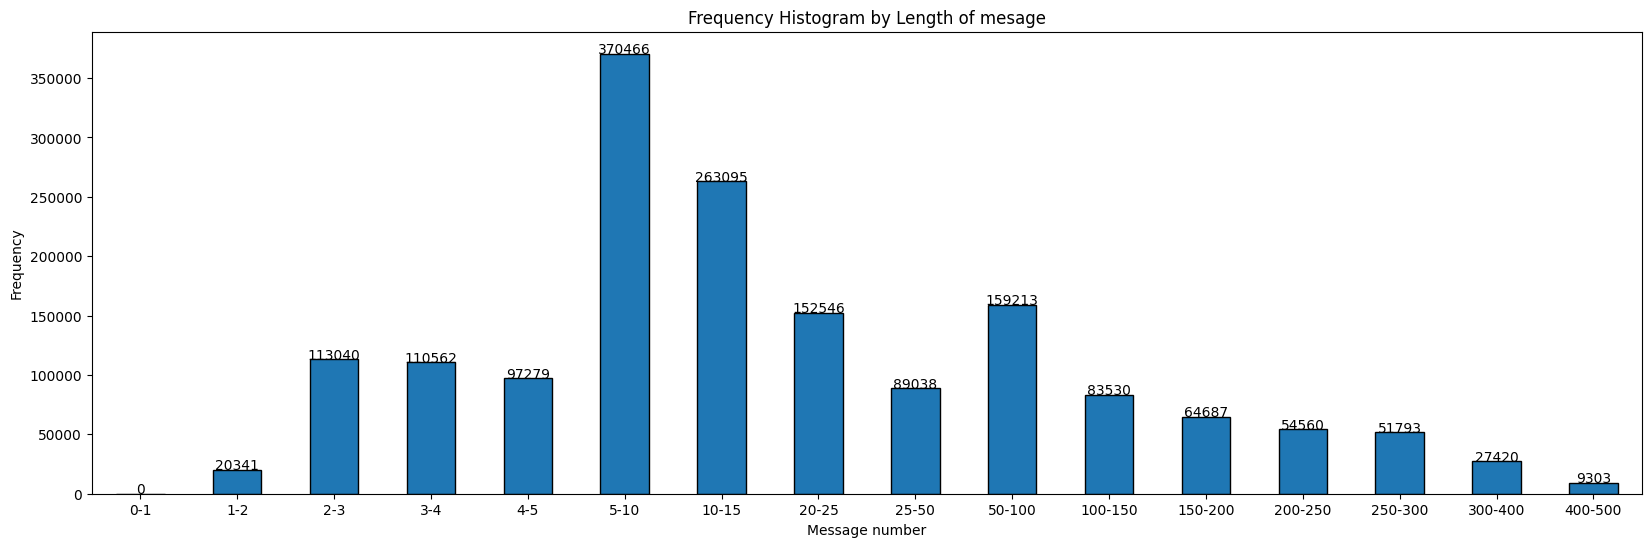

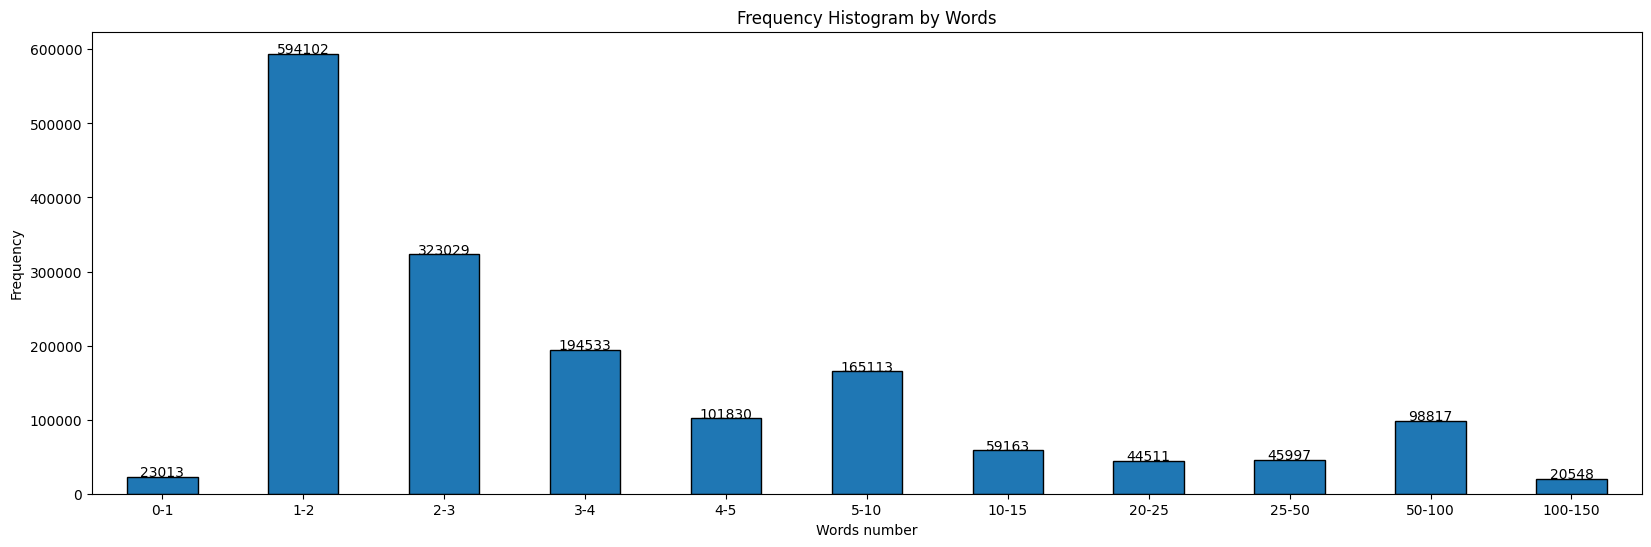

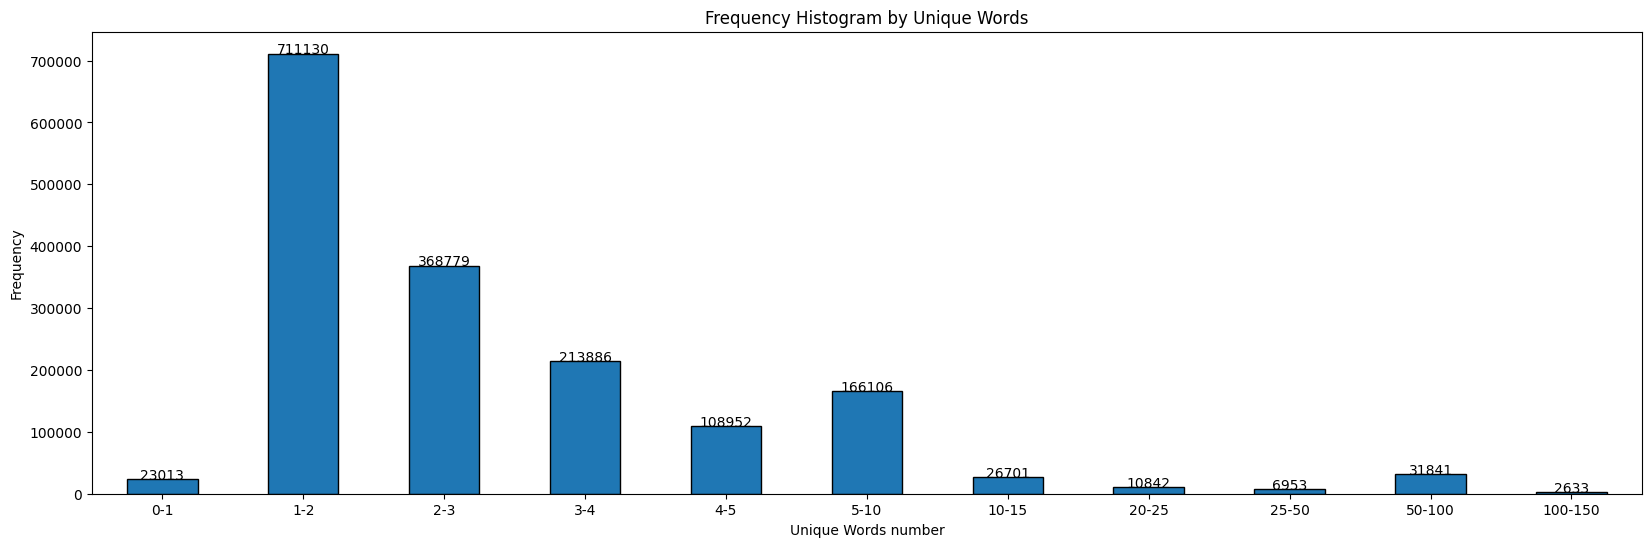

In [375]:
#Bar chart of message length by symbols

# Define bins and labels for each range
bins = [0,1,2,3,4,5,10,15,20,25,50,100,150,200,250,300,400] 
labels = ['0-1','1-2','2-3','3-4','4-5','5-10','10-15','20-25','25-50','50-100','100-150','150-200','200-250','250-300','300-400','400-500'] 
# Bin the data and add a 'group' column with labels for each range
df['message_symbols'] = pd.cut(df['message_length'], bins=bins, labels=labels, right=False)

# Count frequency of each group
grouped_data = df['message_symbols'].value_counts().sort_index()

# Plotting the histogram based on grouped data
plt.figure(figsize=(20, 6))
grouped_data.plot(kind='bar', edgecolor='black')
plt.title('Frequency Histogram by Length of mesage')
plt.xlabel('Message number')
plt.ylabel('Frequency')
plt.xticks(rotation=0)

for index, value in enumerate(grouped_data):
    plt.text(index, value + 5, str(value), ha='center')  # Adjust the y position with +5 if needed

plt.show()


#Bar chart of words count 

# Define bins and labels for each range
bins = [0,1,2,3,4,5,10,15,20,25,50,100] 
labels = ['0-1','1-2','2-3','3-4','4-5','5-10','10-15','20-25','25-50','50-100','100-150'] 
# Bin the data and add a 'group' column with labels for each range
df['words_count_group'] = pd.cut(df['words_count'], bins=bins, labels=labels, right=False)

# Count frequency of each group
grouped_data = df['words_count_group'].value_counts().sort_index()

# Plotting the histogram based on grouped data
plt.figure(figsize=(20, 6))
grouped_data.plot(kind='bar', edgecolor='black')
plt.title('Frequency Histogram by Words')
plt.xlabel('Words number')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
for index, value in enumerate(grouped_data):
    plt.text(index, value + 5, str(value), ha='center')  # Adjust the y position with +5 if needed


plt.show()


# Unique words


#Bar chart of words count 

# Define bins and labels for each range
bins = [0,1,2,3,4,5,10,15,20,25,50,100] 
labels = ['0-1','1-2','2-3','3-4','4-5','5-10','10-15','20-25','25-50','50-100','100-150'] 
# Bin the data and add a 'group' column with labels for each range
df['unique_words_count_group'] = pd.cut(df['unique_words_count'], bins=bins, labels=labels, right=False)

# Count frequency of each group
grouped_data = df['unique_words_count_group'].value_counts().sort_index()

# Plotting the histogram based on grouped data
plt.figure(figsize=(20, 6))
grouped_data.plot(kind='bar', edgecolor='black')
plt.title('Frequency Histogram by Unique Words')
plt.xlabel('Unique Words number')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
for index, value in enumerate(grouped_data):
    plt.text(index, value + 5, str(value), ha='center')  # Adjust the y position with +5 if needed


plt.show()



#Bar chart of chatters


In [376]:
from itertools import chain

#Find all words
all_words = list(chain.from_iterable(df['words_regexp_tokenizer']))
unique_words = set(all_words)

In [377]:
#Check the basic statistics
print("The number of words -",len(all_words), 
      "The unique words -",len(unique_words),
      "The level of spam -",round(len(all_words)/len(unique_words),2))

The number of words - 10242151 The unique words - 221113 The level of spam - 46.32


In [378]:
from collections import Counter
#Count frequence of all words
word_counts = Counter(all_words)
#Find to 10 words
top_10_words = word_counts.most_common(20)
top_10_words

#Conclusion Team mentions are most populars NAVI, G2, Next there are some Emotes and slangs

[('NAVI', 1115422),
 ('G2', 199082),
 ('3', 192974),
 ('LUL', 138229),
 ('GO', 113331),
 ('BANKS', 95802),
 ('DoritosChip', 87907),
 ('KEKW', 87653),
 ('I', 86622),
 ('forsenE', 82320),
 ('Pog', 79946),
 ('4Head', 70445),
 ('is', 69173),
 ('the', 69166),
 ('EZ', 60705),
 ('CurseLit', 57261),
 ('to', 50841),
 ('and', 49430),
 ('OMEGALUL', 47905),
 ('a', 44024)]

In [379]:
#From Counter create new DF with frequence of words

df_word_counts = pd.DataFrame.from_dict(word_counts, orient='index', columns=['frequency']).reset_index().rename(columns={'index': 'word'})

#Maping emotes
#Global emotes - https://twitchemotes.com/#google_vignette

df_word_counts['global_twitch_emotes'] = df_word_counts['word'].isin(global_twitch_emotes)
df_word_counts['all_emotes'] = df_word_counts['word'].isin(all_emotes)

In [380]:
#Global emotes share 
round(df_word_counts[df_word_counts['global_twitch_emotes']==True]['frequency'].sum()/len(all_words),5)

np.float64(0.12515)

In [381]:
#All emotes share
round(df_word_counts[df_word_counts['all_emotes']==True]['frequency'].sum()/len(all_words),5)

np.float64(0.12526)

In [382]:
#Conclusions there are 12.51% of Global emotes, and only 12.53% of All emotes

In [383]:
# Mapping Messages with emotes
df['message_with_emote'] = df['words_regexp_tokenizer'].apply(lambda x: any(word in global_twitch_emotes for word in x))


In [384]:
print(df['emitted_at'].min(),df['emitted_at'].max())

2021-10-26 11:20:07 2021-11-07 22:15:00


In [385]:
#Counting messages with global emotes and total messages 
print(len(df[df['message_with_emote']==True]))
print(len(df))

464531
1670836


In [386]:
#Finding shares of messages with Global Emotes
464531/1670836

0.2780230974194954

In [387]:
#No sense to include all emotes, it is obvious that the emotes are usually spammed
#But global emotes can describe the sentiment or help to describe of 27.8% of all message sentiment

### Downloading the pictures of the emotes for expert evaluation

In [389]:
import requests
from urllib.robotparser import RobotFileParser

def check_scraping_permission(url, user_agent='*'):
    # Parse the base URL to fetch robots.txt
    base_url = "/".join(url.split("/")[:3])  # Extract base URL
    robots_url = f"{base_url}/robots.txt"

    print(f"Fetching {robots_url}...")
    
    # Fetch and parse robots.txt
    rp = RobotFileParser()
    rp.set_url(robots_url)
    try:
        rp.read()  # Read and parse the robots.txt file
    except Exception as e:
        print(f"Could not fetch robots.txt: {e}")
        return False
    
    # Check if scraping the given URL is allowed
    is_allowed = rp.can_fetch(user_agent, url)
    if is_allowed:
        print(f"✅ Scraping is allowed for {url}")
    else:
        print(f"❌ Scraping is NOT allowed for {url}")
    
    return is_allowed

# Example URL to test
url_to_check = "https://twitchemotes.com"
check_scraping_permission(url_to_check)

Fetching https://twitchemotes.com/robots.txt...
✅ Scraping is allowed for https://twitchemotes.com


True

### Creating file for expert evaluation

In [391]:
import requests
from bs4 import BeautifulSoup
from IPython.display import Image, display

# Twitchemotes webpage URL
url = "https://twitchemotes.com"

# Fetch the webpage
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")


# Find and extract emote image links (hypothetical example)
images = soup.find_all("img")

images_pictures = {}
# Display first 5 emotes
for img in images[1:len(images)]:
    img_url = img["src"]
    img_name = img["data-regex"]
    if img_url.startswith("http"):
       #print(f"Emote URL: {img_url}")
        #display(Image(url=img_url),img_name)
        images_pictures[img_name]= img_url


images_pictures_df = pd.DataFrame(list(images_pictures.items()), columns=['emote', 'link'])

images_pictures_df['emote_display'] = images_pictures_df['link'].apply(lambda x: f'<img src="{x}" style="height:30px;">')

# Display DataFrame with HTML rendering in Jupyter
display(HTML(images_pictures_df[['emote', 'emote_display']].to_html(escape=False)))


images_pictures_df.to_csv('images_pictures_df.csv', index=False)
from IPython.display import FileLink, FileLinks

# Generate a link to download the file for mapping
file_link = FileLink('images_pictures_df')
file_link

,emote,emote_display
0,4Head,
1,8-),
2,:(,
3,:),
4,:-(,
5,:-),
6,:-/,
7,:-D,
8,:-O,
9,:-P,


/Users/rodionhorbunov/images_pictures_df

### The result of emotes sentiment: PCA and Clustering of emotes sentiment

In [823]:
emotes_expert = pd.read_csv('/Users/rodionhorbunov/Downloads/Global emotes mapping - Expert Evaluation Final.csv')
emotes_ai_gpt4o = pd.read_csv('/Users/rodionhorbunov/Downloads/Global emotes mapping - Ai Evaluation Chat GPT.csv')
emotes_ai_deepseek = pd.read_csv('/Users/rodionhorbunov/Downloads/Global emotes mapping - Ai Evaluation Deepseek.csv')

print("The length of emotes_ai_deepseek is equal ", len(emotes_ai_deepseek))
print("The length of emotes_ai_gpt4o is equal ", len(emotes_ai_gpt4o))
print("The length of emotes_expert is equal ", len(emotes_expert))

The length of emotes_ai_deepseek is equal  314
The length of emotes_ai_gpt4o is equal  314
The length of emotes_expert is equal  314


#### PCA of the emotes

In [395]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [396]:
#PCA function
def pca_for_dataframe(dataframe):
    #Working with data
    df_pca = dataframe[['emotion_recognition', 'anger_calmness', 'despair_hope', 'disgust_like', 'hate_love', 'sadness_joy', 'anticipation_surprise']]
    #Getting rid of strings
    df_pca = df_pca.replace('-', np.nan)
    df_pca = df_pca.apply(pd.to_numeric, errors='coerce')
    df_pca = df_pca.fillna(0)
    
    #Running PCA
    pca = PCA(n_components=None)  
    principal_components = pca.fit_transform(df_pca)
    
    #Converting PCA results to DF
    pca_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(principal_components.shape[1])])
    
    #Concating the dataframes
    pca_df = pd.concat([pca_df, emotes_expert], axis=1)
    
    #Print the explained variance
    explained_variance = pca.explained_variance_ratio_
    print("Explained variance ratio:", explained_variance)
    
    return pca_df

In [397]:
emotes_expert_with_pca = pca_for_dataframe(emotes_expert)
emotes_ai_deepseek_with_pca = pca_for_dataframe(emotes_ai_deepseek)
emotes_ai_gpt4o_with_pca = pca_for_dataframe(emotes_ai_gpt4o)

Explained variance ratio: [0.36959894 0.25861161 0.16108214 0.0919287  0.05579874 0.04184746
 0.02113241]
Explained variance ratio: [9.40385451e-01 4.14559265e-02 9.28256609e-03 5.59759844e-03
 2.44340751e-03 8.10698768e-04 2.43512690e-05]
Explained variance ratio: [9.68397268e-01 1.86817667e-02 7.49754921e-03 3.18319796e-03
 1.82529496e-03 4.14922829e-04 0.00000000e+00]


#### Clustering of the emotes

In [399]:
#Checking the Silhouette score for dataframes
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(emotes_expert_with_pca[['PC1', 'PC2']])
    score = silhouette_score(emotes_expert_with_pca[['PC1', 'PC2']], labels)
    print(f"Silhouette score for emotes_expert k={k}: {score:.3f}")

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(emotes_ai_deepseek_with_pca[['PC1', 'PC2']])
    score = silhouette_score(emotes_ai_deepseek_with_pca[['PC1', 'PC2']], labels)
    print(f"Silhouette score for emotes_ai_deepseek k={k}: {score:.3f}")

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(emotes_ai_gpt4o_with_pca[['PC1', 'PC2']])
    score = silhouette_score(emotes_ai_gpt4o_with_pca[['PC1', 'PC2']], labels)
    print(f"Silhouette score for emotes_ai_gpt4o k={k}: {score:.3f}")

Silhouette score for emotes_expert k=2: 0.397
Silhouette score for emotes_expert k=3: 0.430
Silhouette score for emotes_expert k=4: 0.499
Silhouette score for emotes_expert k=5: 0.461
Silhouette score for emotes_expert k=6: 0.511
Silhouette score for emotes_expert k=7: 0.498
Silhouette score for emotes_expert k=8: 0.482
Silhouette score for emotes_expert k=9: 0.466
Silhouette score for emotes_expert k=10: 0.471
Silhouette score for emotes_ai_deepseek k=2: 0.829
Silhouette score for emotes_ai_deepseek k=3: 0.757
Silhouette score for emotes_ai_deepseek k=4: 0.772
Silhouette score for emotes_ai_deepseek k=5: 0.798
Silhouette score for emotes_ai_deepseek k=6: 0.848
Silhouette score for emotes_ai_deepseek k=7: 0.798
Silhouette score for emotes_ai_deepseek k=8: 0.845
Silhouette score for emotes_ai_deepseek k=9: 0.851
Silhouette score for emotes_ai_deepseek k=10: 0.898
Silhouette score for emotes_ai_gpt4o k=2: 0.783
Silhouette score for emotes_ai_gpt4o k=3: 0.597
Silhouette score for emotes_a

In [400]:
#Best clustering with minimal possible clusters

emotes_expert_clusters = 4
emotes_ai_clusters = 2

In [401]:
kmeans = KMeans(n_clusters=emotes_expert_clusters, random_state=42)
clusters = kmeans.fit_predict(emotes_expert_with_pca[['PC1', 'PC2']])
emotes_expert_with_pca['Cluster'] = clusters

kmeans = KMeans(n_clusters=emotes_ai_clusters, random_state=42)
clusters = kmeans.fit_predict(emotes_ai_deepseek_with_pca[['PC1', 'PC2']])
emotes_ai_deepseek_with_pca['Cluster'] = clusters

kmeans = KMeans(n_clusters=emotes_ai_clusters, random_state=42)
clusters = kmeans.fit_predict(emotes_ai_gpt4o_with_pca[['PC1', 'PC2']])
emotes_ai_gpt4o_with_pca['Cluster'] = clusters

### Plotting Clustering results

In [403]:
import seaborn as sns

def pca_cluster_plotting(dataframe, chart_name):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=dataframe, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=70)
    plt.title(chart_name)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.savefig("pca_emote_plot.png", dpi=300, bbox_inches='tight')
    plt.show()

In [404]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import requests
from io import BytesIO
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Ellipse


def draw_ellipses(ax, dataframe, group_col='Cluster', x='PC1', y='PC2', palette='Set1'):
    colors = sns.color_palette(palette, n_colors=dataframe[group_col].nunique())

    for i, cluster in enumerate(sorted(dataframe[group_col].unique())):
        subset = dataframe[dataframe[group_col] == cluster]
        if len(subset) < 2:
            continue  # Skip small clusters

        center_x = subset[x].mean()
        center_y = subset[y].mean()
        width = subset[x].std() * 4  # Wider ellipse
        height = subset[y].std() * 4

        ellipse = Ellipse((center_x, center_y), width, height, edgecolor=colors[i],
                          facecolor=colors[i], alpha=0.2, lw=2)
        ax.add_patch(ellipse)

def pca_cluster_plotting_with_emotes(dataframe, chart_name):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot points with alpha=0 to make them invisible (we'll use images instead)
    sns.scatterplot(data=dataframe, x='PC1', y='PC2', hue='Cluster', ax=ax, alpha=0, palette='Set1')
    
    # Draw ellipses around clusters
    draw_ellipses(ax, dataframe)

    # Add image emotes
    for _, row in dataframe.iterrows():
        try:
            response = requests.get(row['link'])
            img = Image.open(BytesIO(response.content))
            imagebox = OffsetImage(img, zoom=0.5)
            ab = AnnotationBbox(imagebox, (row['PC1'], row['PC2']), frameon=False)
            ax.add_artist(ab)
        except Exception as e:
            print(f"Could not load image at {row['link']}: {e}")

    plt.title(chart_name)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.legend(title='Cluster')
    plt.savefig("pca_emote_plot.png", dpi=300, bbox_inches='tight')
    plt.show()

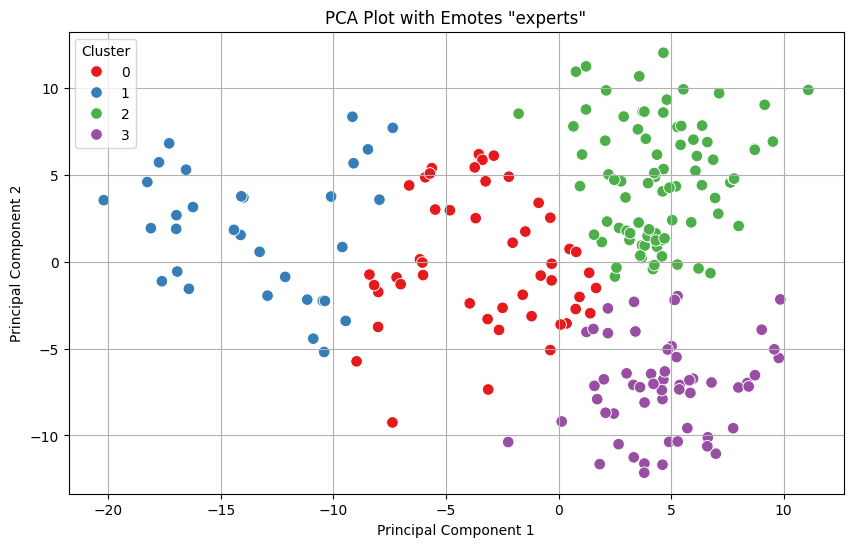

/Users/rodionhorbunov/pca_emote_plot.png

In [405]:
from IPython.display import FileLink
pca_cluster_plotting(emotes_expert_with_pca, 'PCA Plot with Emotes "experts"')
FileLink('pca_emote_plot.png')

Could not load image at https://static-cdn.jtvnw.net/emoticons/v1/30134/1.0: Invalid shape (28, 28, 2) for image data
Could not load image at https://static-cdn.jtvnw.net/emoticons/v1/66/1.0: Invalid shape (27, 20, 2) for image data
Could not load image at https://static-cdn.jtvnw.net/emoticons/v1/36/1.0: Invalid shape (30, 36, 2) for image data


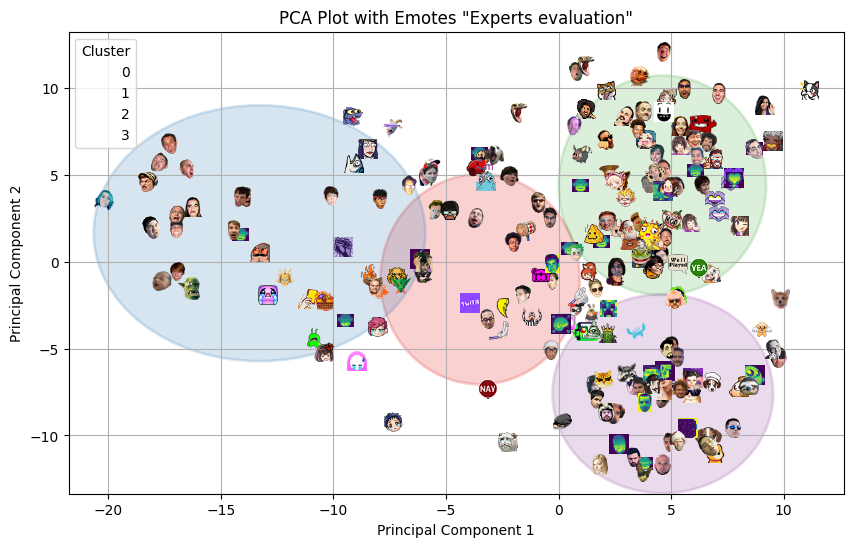

/Users/rodionhorbunov/pca_emote_plot.png

In [406]:
pca_cluster_plotting_with_emotes(emotes_expert_with_pca, 'PCA Plot with Emotes "Experts evaluation"')
FileLink('pca_emote_plot.png')

In [407]:
emotes_ai_gpt4o_with_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Index,emote_display,link,...,emotion_recognition,anger_calmness,despair_hope,disgust_like,hate_love,sadness_joy,anticipation_surprise,sacrasm_lvl,Confidence_answer,Cluster
0,4.080765,-3.328068,-1.273841,0.171944,1.515047,0.343065,-1.776357e-15,27,"<img src=""https://static-cdn.jtvnw.net/emotico...",https://static-cdn.jtvnw.net/emoticons/v1/5555...,...,10,4,0,7,2,7,2,0,10,0
1,4.080765,-3.328068,-1.273841,0.171944,1.515047,0.343065,-1.776357e-15,26,"<img src=""https://static-cdn.jtvnw.net/emotico...",https://static-cdn.jtvnw.net/emoticons/v1/11/1.0,...,10,4,0,7,2,7,2,0,10,0
2,2.701783,-3.684458,1.248329,-0.531260,1.419358,0.016877,1.421085e-14,225,"<img src=""https://static-cdn.jtvnw.net/emotico...",https://static-cdn.jtvnw.net/emoticons/v1/5555...,...,10,4,0,7,2,7,2,0,10,0
3,2.701783,-3.684458,1.248329,-0.531260,1.419358,0.016877,1.421085e-14,224,"<img src=""https://static-cdn.jtvnw.net/emotico...",https://static-cdn.jtvnw.net/emoticons/v1/14/1.0,...,10,4,0,7,2,7,2,0,10,0
4,8.920835,-3.136789,0.147683,0.119749,0.817545,0.178227,-5.329071e-15,5,"<img src=""https://static-cdn.jtvnw.net/emotico...",https://static-cdn.jtvnw.net/emoticons/v1/5555...,...,10,4,0,7,2,7,2,0,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,12.596734,-0.386559,-0.036173,-0.359167,-0.460595,0.013322,-5.329071e-15,296,"<img src=""https://static-cdn.jtvnw.net/emotico...",https://static-cdn.jtvnw.net/emoticons/v1/emot...,...,10,9,0,1,-4,1,-10,3,4,0
310,-27.841434,-2.431173,-1.024207,-0.357659,0.280663,-0.206738,8.881784e-15,293,"<img src=""https://static-cdn.jtvnw.net/emotico...",https://static-cdn.jtvnw.net/emoticons/v1/1148...,...,10,8,1,-2,1,1,2,0,6,1
311,3.220252,0.424643,-0.649314,-0.205200,-0.615123,0.016296,-7.105427e-15,297,"<img src=""https://static-cdn.jtvnw.net/emotico...",https://static-cdn.jtvnw.net/emoticons/v1/2808...,...,10,-4,-8,-10,-2,-8,10,0,9,0
312,-35.532553,-1.231063,-2.122911,0.318096,-0.579988,-0.163041,-7.105427e-15,298,"<img src=""https://static-cdn.jtvnw.net/emotico...",https://static-cdn.jtvnw.net/emoticons/v1/1342...,...,10,6,2,6,2,5,7,4,6,1


Could not load image at https://static-cdn.jtvnw.net/emoticons/v1/30134/1.0: Invalid shape (28, 28, 2) for image data
Could not load image at https://static-cdn.jtvnw.net/emoticons/v1/66/1.0: Invalid shape (27, 20, 2) for image data
Could not load image at https://static-cdn.jtvnw.net/emoticons/v1/36/1.0: Invalid shape (30, 36, 2) for image data


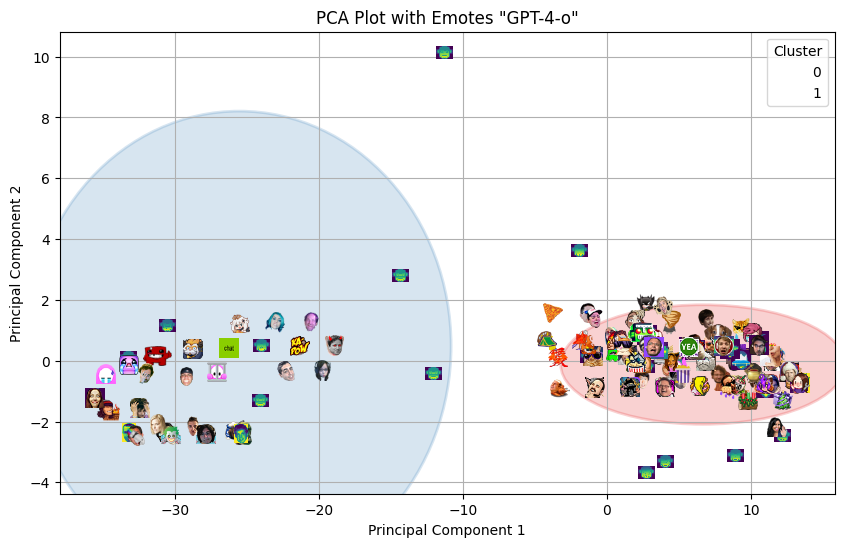

/Users/rodionhorbunov/pca_emote_plot.png

In [408]:
pca_cluster_plotting_with_emotes(emotes_ai_gpt4o_with_pca, 'PCA Plot with Emotes "GPT-4-o"')
FileLink('pca_emote_plot.png')

Could not load image at https://static-cdn.jtvnw.net/emoticons/v1/30134/1.0: Invalid shape (28, 28, 2) for image data
Could not load image at https://static-cdn.jtvnw.net/emoticons/v1/66/1.0: Invalid shape (27, 20, 2) for image data
Could not load image at https://static-cdn.jtvnw.net/emoticons/v1/36/1.0: Invalid shape (30, 36, 2) for image data


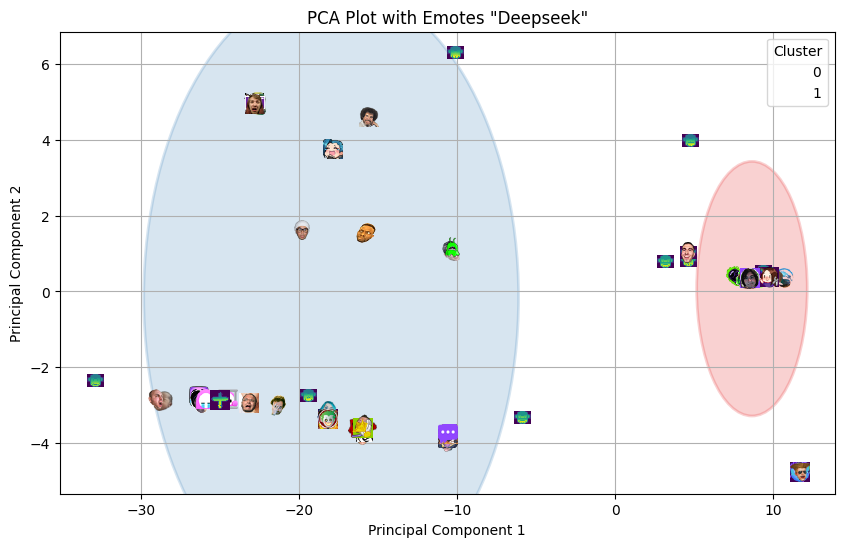

/Users/rodionhorbunov/pca_emote_plot.png

In [409]:
pca_cluster_plotting_with_emotes(emotes_ai_deepseek_with_pca, 'PCA Plot with Emotes "Deepseek"')
FileLink('pca_emote_plot.png')


### Preparing final vector spaces

In [827]:
# New metrics
emotes_expert['mult_coef'] = emotes_expert['emotion_recognition']/10 * emotes_expert['Confidence_answer']/10
emotes_expert['sarcasm_coef'] =  emotes_expert.apply(lambda row: -1 if row['sacrasm_lvl'] > 5 else 1,axis=1)


In [829]:
# New coefs
emotes_expert['mult_coef']  = emotes_expert['mult_coef'].astype('float')
emotes_expert['sarcasm_coef']  = emotes_expert['sarcasm_coef'].astype('float')


In [853]:
emotes_expert_df1  = emotes_expert.copy()
emotes_expert_df2  = emotes_expert.copy()

In [855]:
emotion_columns = ['anger_calmness', 'despair_hope', 'disgust_like', 
                   'hate_love', 'sadness_joy', 'anticipation_surprise']

# Apply the transformation to each column
for col in emotion_columns:
    emotes_expert_df1[col] = pd.to_numeric(emotes_expert_df1[col], errors='coerce')
    emotes_expert_df2[col] = pd.to_numeric(emotes_expert_df2[col], errors='coerce')
    
    emotes_expert_df1[col] = emotes_expert_df1[col]*emotes_expert_df1['mult_coef'] 
    emotes_expert_df2[col] = emotes_expert_df2[col]*emotes_expert_df2['mult_coef']
    emotes_expert_df2[col] = emotes_expert_df2[col]*emotes_expert_df2['sarcasm_coef']


In [861]:
emotes_expert_df1 = emotes_expert_df1[['Emote','anger_calmness', 'despair_hope', 'disgust_like', 
                   'hate_love', 'sadness_joy', 'anticipation_surprise','sacrasm_lvl']]
emotes_expert_df2 = emotes_expert_df2[['Emote','anger_calmness', 'despair_hope', 'disgust_like', 
                   'hate_love', 'sadness_joy', 'anticipation_surprise']]

In [863]:

# Step 1: create emotion vector lookup
emotes_expert_df1 = emotes_expert_df1.set_index('Emote')
emotes_expert_df2 = emotes_expert_df2.set_index('Emote')

In [871]:
# Copy the row with index 'LUL'
new_row = emotes_expert_df1.loc['LUL'].copy()
# Assign it to new index 'OMEGALUL'
emotes_expert_df1.loc['OMEGALUL'] = new_row

# Copy the row with index 'LUL'
new_row = emotes_expert_df2.loc['LUL'].copy()
# Assign it to new index 'OMEGALUL'
emotes_expert_df2.loc['OMEGALUL'] = new_row

In [872]:
# Copy the row with index 'Pog'
new_row = emotes_expert_df1.loc['PogChamp'].copy()
emotes_expert_df1.loc['Pog'] = new_row

new_row = emotes_expert_df2.loc['PogChamp'].copy()
emotes_expert_df2.loc['Pog'] = new_row


# Copy the row with index 'Kappa'
new_row = emotes_expert_df1.loc['Kappa'].copy()
emotes_expert_df1.loc['KEKW'] = new_row

new_row = emotes_expert_df2.loc['Kappa'].copy()
emotes_expert_df2.loc['KEKW'] = new_row

In [874]:
emotes_expert_df1.loc['LUL']

anger_calmness           2.5
despair_hope             0.0
disgust_like             1.5
hate_love                0.5
sadness_joy              3.0
anticipation_surprise    4.0
sacrasm_lvl              6.0
Name: LUL, dtype: float64

In [875]:
emotes_expert_df2.loc['LUL']

anger_calmness          -2.5
despair_hope            -0.0
disgust_like            -1.5
hate_love               -0.5
sadness_joy             -3.0
anticipation_surprise   -4.0
Name: LUL, dtype: float64

In [876]:
df_w_emotes = df[df['message_with_emote']==True]

In [877]:
from collections import Counter

# Step 2: function to calculate weighted emotion vector per row
def compute_emotion_vector_1(tokens):
    counter = Counter(tokens)
    result_vector = np.zeros(len(emotes_expert_df1.columns))
    for word, count in counter.items():
        if word in emotes_expert_df1.index:
            result_vector += emotes_expert_df1.loc[word].values * count
    return result_vector

# Step 2: function to calculate weighted emotion vector per row
def compute_emotion_vector_2(tokens):
    counter = Counter(tokens)
    result_vector = np.zeros(len(emotes_expert_df2.columns))
    for word, count in counter.items():
        if word in emotes_expert_df2.index:
            result_vector += emotes_expert_df2.loc[word].values * count
    return result_vector

In [878]:
# Step 3: apply to each row
emotion_array1 = df_w_emotes['words_regexp_tokenizer'].apply(compute_emotion_vector_1)
emotion_array2 = df_w_emotes['words_regexp_tokenizer'].apply(compute_emotion_vector_2)


In [880]:
# Step 4: convert result to DataFrame
emotion_df1 = pd.DataFrame(emotion_array1.tolist(), columns=emotes_expert_df1.columns)
emotion_df2 = pd.DataFrame(emotion_array2.tolist(), columns=emotes_expert_df2.columns)


In [883]:
# Combine with original df
df_w_emotes_final = pd.concat([df_w_emotes.reset_index(drop=True), emotion_df1,emotion_df2], axis=1)


In [884]:
df_w_emotes_final.columns = ['emitted_at', 'event_type', 'message', 'number_attribute',
       'string_attribute', 'target_id', 'target_name', 'user_id', 'user_name',
       'message_length', 'words_count', 'words_regexp_tokenizer',
       'unique_words_count', 'uniq_content', 'message_symbols',
       'words_count_group', 'unique_words_count_group', 'message_with_emote',
       'anger_calmness_1', 'despair_hope_1', 'disgust_like_1', 'hate_love_1',
       'sadness_joy_1', 'anticipation_surprise_1', 'sacrasm_lvl_1', 'anger_calmness_2',
       'despair_hope_2', 'disgust_like_2', 'hate_love_2', 'sadness_joy_2',
       'anticipation_surprise_2']

In [885]:
df_w_emotes_final[df_w_emotes_final['sacrasm_lvl_1']>5][['sadness_joy_1','sadness_joy_2']]

,sadness_joy_1,sadness_joy_2
0,3.0,-3.0
1,3.0,-3.0
2,3.0,-3.0
3,3.0,-3.0
4,3.0,-3.0
...,...,...
464517,9.8,9.8
464527,14.7,14.7
464528,1.5,-1.5
464529,1.5,-1.5


### Aggregating sentiment of audience by 5 min 

In [887]:
df_w_emotes_final['emitted_at_5min'] = pd.to_datetime(df_w_emotes_final['emitted_at']).dt.floor('5min')

In [888]:
df_w_emotes_final_time = df_w_emotes_final.groupby('emitted_at_5min').agg(
    chatters = ('user_id','nunique'),
    messages = ('message','count'),
    anger_calmness_1= ('anger_calmness_1', 'sum'),
    despair_hope_1= ('despair_hope_1', 'sum'),
    disgust_like_1= ('disgust_like_1', 'sum'),
    hate_love_1= ('hate_love_1', 'sum'),
    sadness_joy_1= ('sadness_joy_1', 'sum'),
    anticipation_surprise_1= ('anticipation_surprise_1', 'sum'),
    sacrasm_lvl_1= ('sacrasm_lvl_1', 'sum'),
    anger_calmness_2= ('anger_calmness_2', 'sum'),
    despair_hope_2= ('despair_hope_2', 'sum'),
    disgust_like_2= ('disgust_like_2', 'sum'),
    hate_love_2= ('hate_love_2', 'sum'),
    sadness_joy_2= ('sadness_joy_2', 'sum'),
    anticipation_surprise_2= ('anticipation_surprise_2','sum')).reset_index().sort_values('emitted_at_5min',ascending = True)

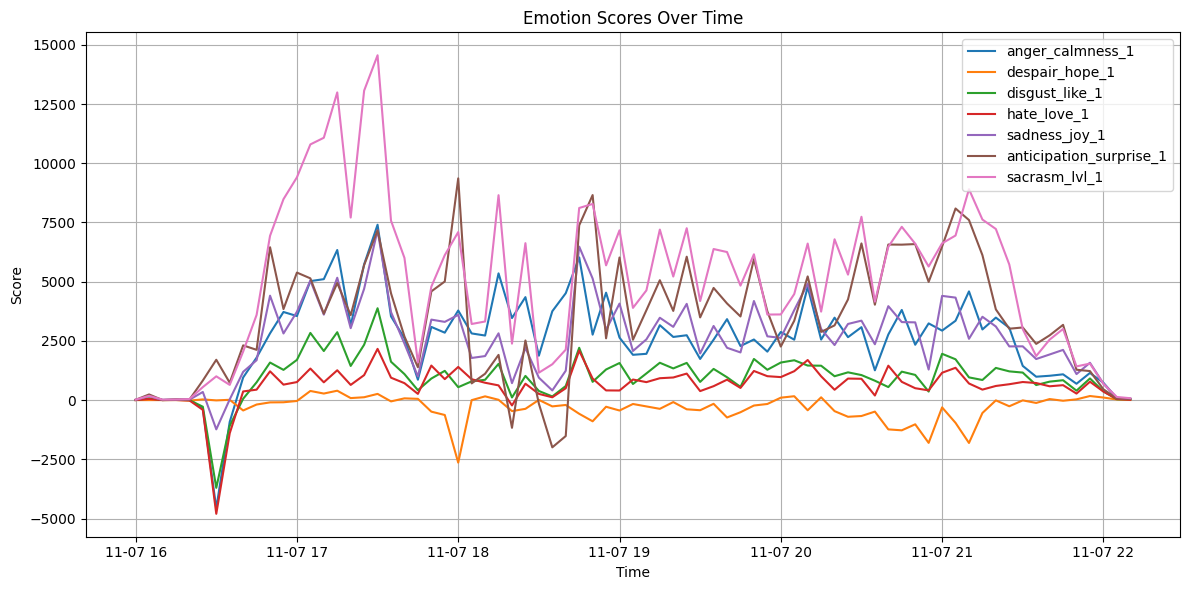

In [889]:
# Plotting the line chart
plt.figure(figsize=(12, 6))

for col in ['anger_calmness_1','despair_hope_1','disgust_like_1','hate_love_1','sadness_joy_1','anticipation_surprise_1','sacrasm_lvl_1']:
    plt.plot(df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07']['emitted_at_5min'], df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07'][col], label=col)

plt.title("Emotion Scores Over Time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

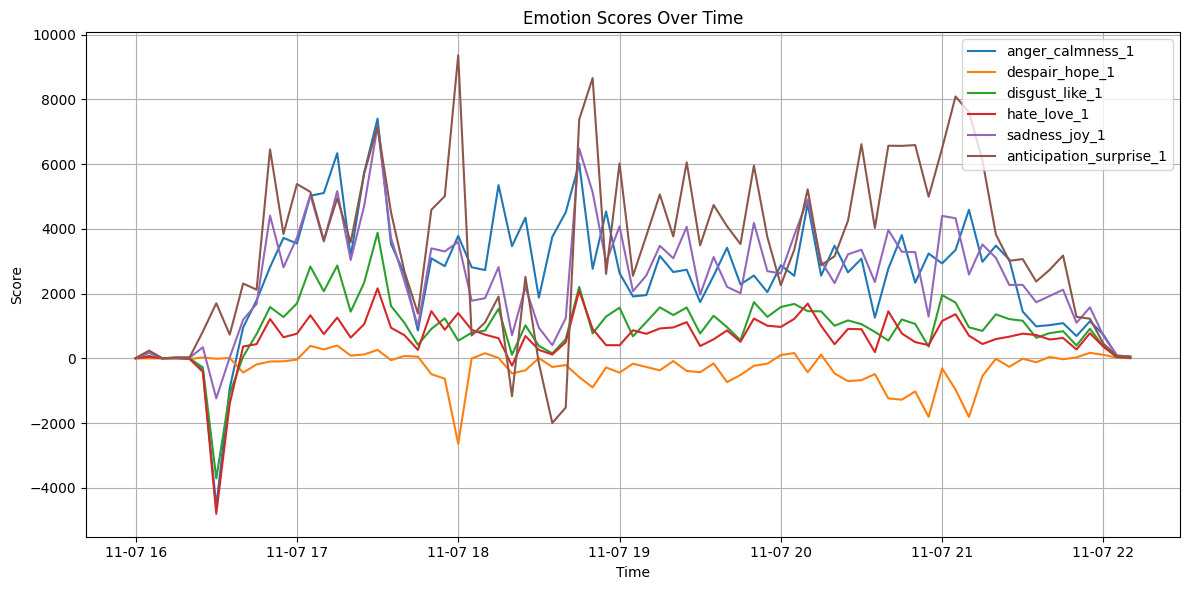

In [890]:
# Plotting the line chart
plt.figure(figsize=(12, 6))

for col in ['anger_calmness_1','despair_hope_1','disgust_like_1','hate_love_1','sadness_joy_1','anticipation_surprise_1']:
    plt.plot(df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07']['emitted_at_5min'], df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07'][col], label=col)

plt.title("Emotion Scores Over Time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

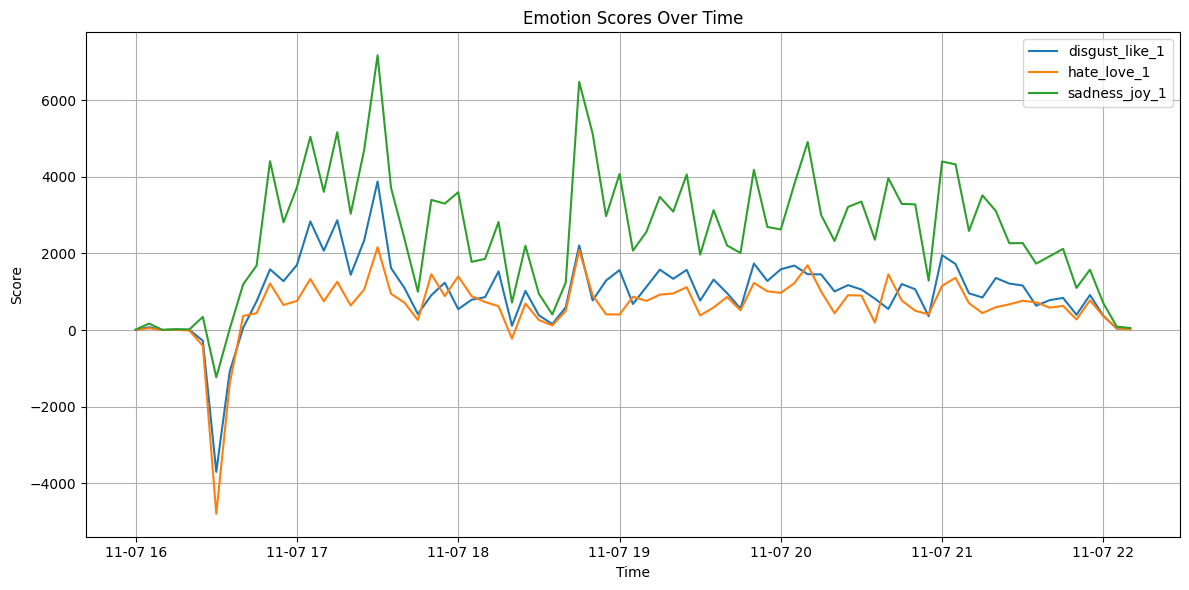

In [891]:
# Plotting the line chart
plt.figure(figsize=(12, 6))

for col in ['disgust_like_1','hate_love_1','sadness_joy_1']:
    plt.plot(df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07']['emitted_at_5min'], df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07'][col], label=col)

plt.title("Emotion Scores Over Time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

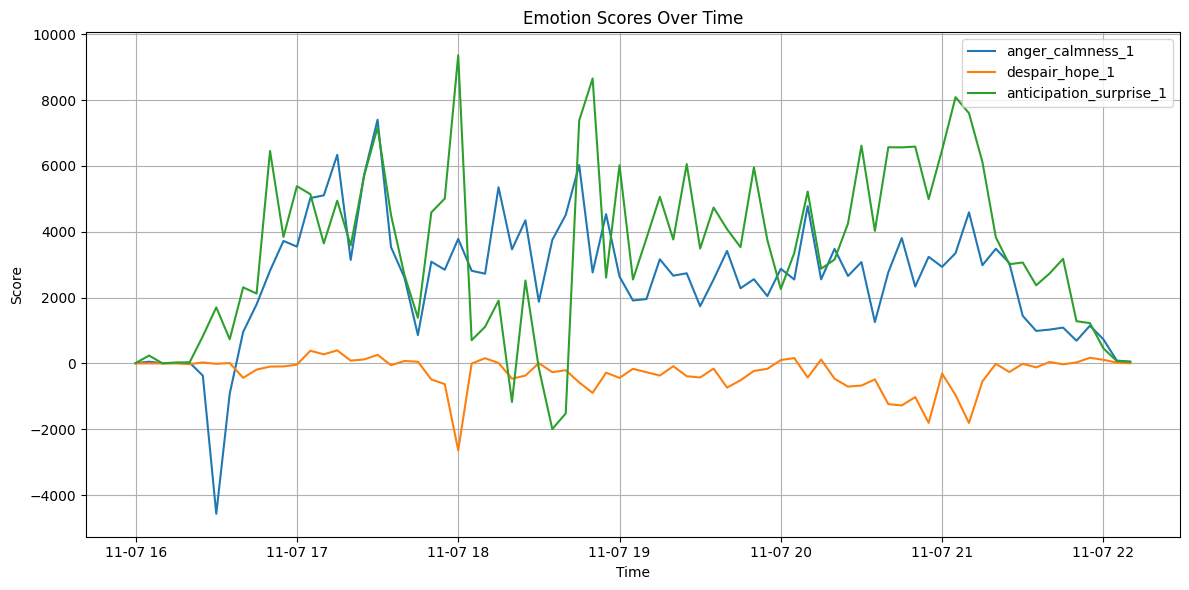

In [892]:
# Plotting the line chart
plt.figure(figsize=(12, 6))

for col in ['anger_calmness_1','despair_hope_1','anticipation_surprise_1']:
    plt.plot(df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07']['emitted_at_5min'], df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07'][col], label=col)

plt.title("Emotion Scores Over Time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

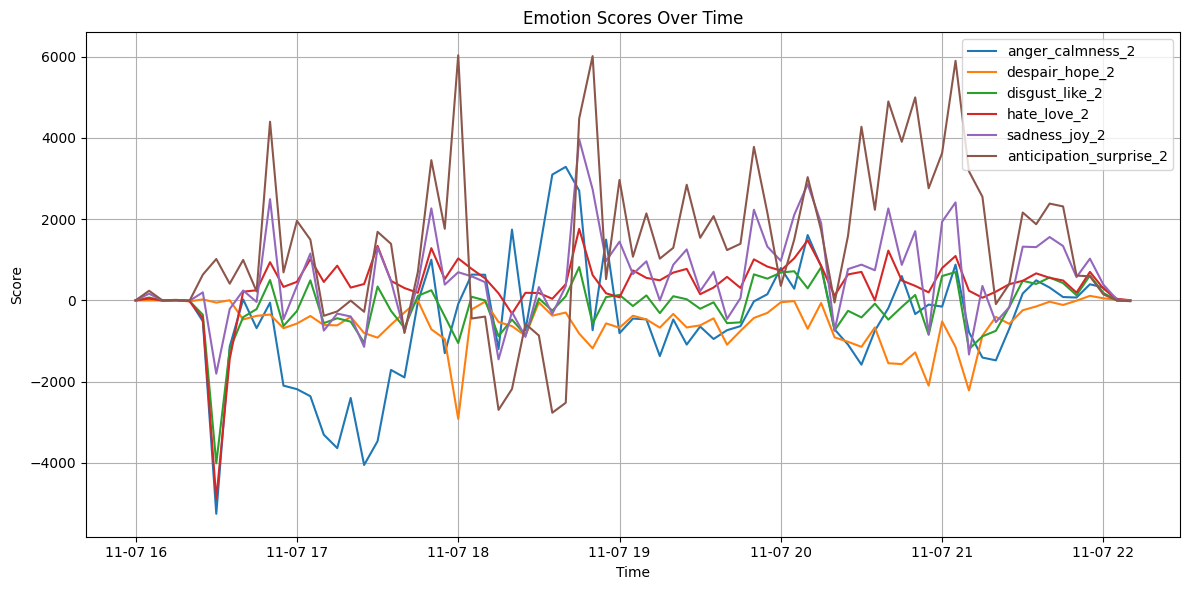

In [893]:
# Plotting the line chart
plt.figure(figsize=(12, 6))

for col in ['anger_calmness_2','despair_hope_2','disgust_like_2','hate_love_2','sadness_joy_2','anticipation_surprise_2']:
    plt.plot(df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07']['emitted_at_5min'], df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07'][col], label=col)

plt.title("Emotion Scores Over Time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

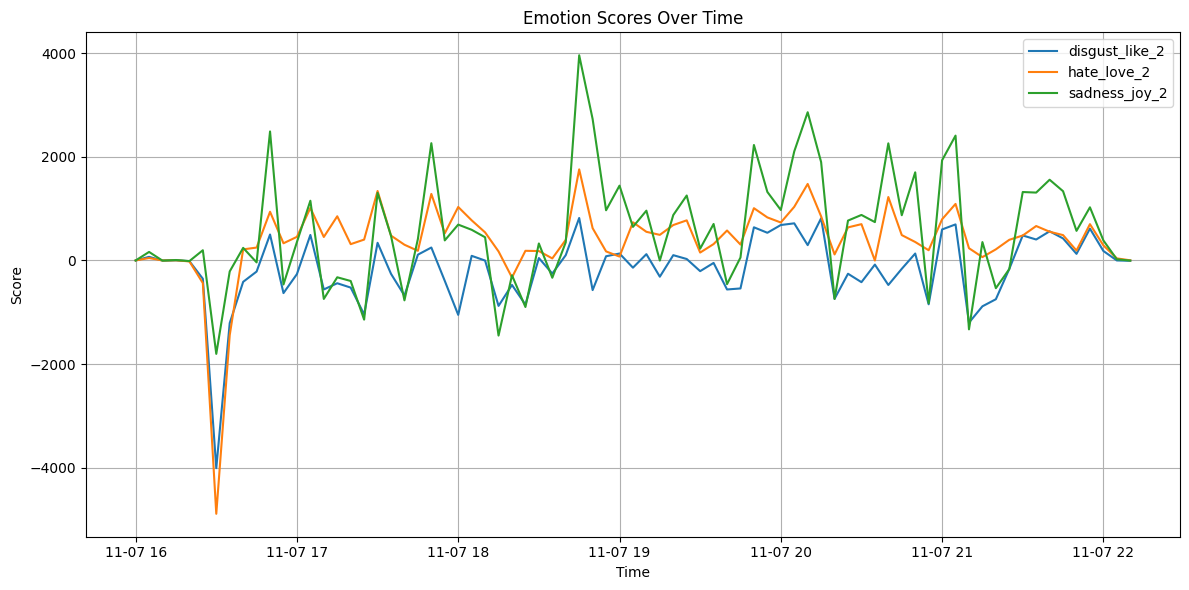

In [894]:
# Plotting the line chart
plt.figure(figsize=(12, 6))

for col in ['disgust_like_2','hate_love_2','sadness_joy_2']:
    plt.plot(df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07']['emitted_at_5min'], df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07'][col], label=col)

plt.title("Emotion Scores Over Time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

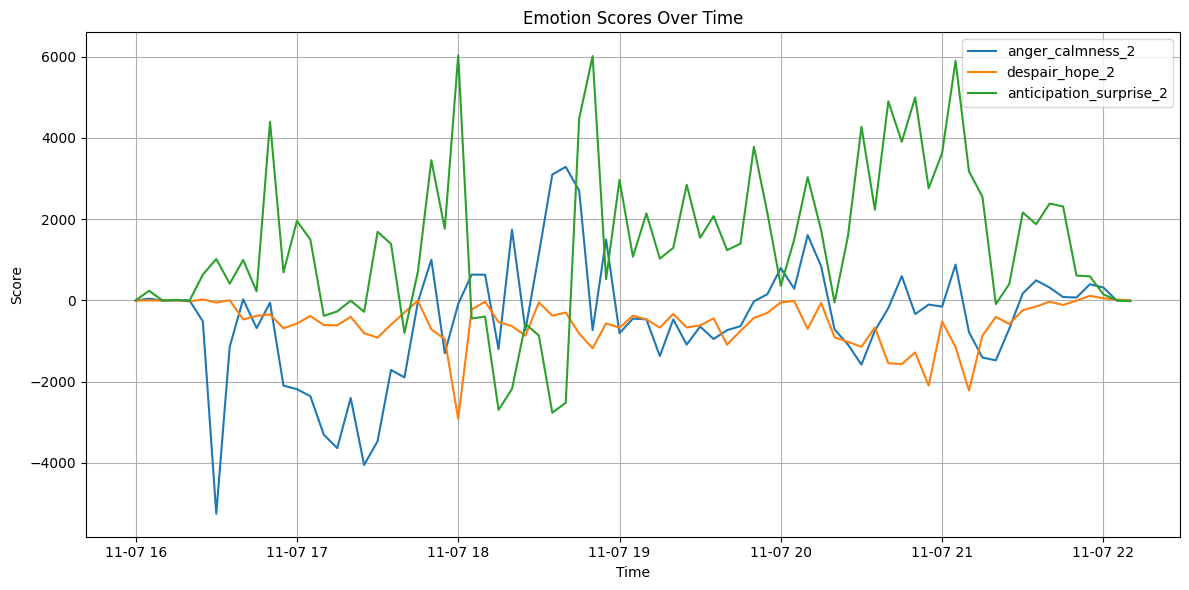

In [895]:
# Plotting the line chart
plt.figure(figsize=(12, 6))

for col in ['anger_calmness_2','despair_hope_2','anticipation_surprise_2']:
    plt.plot(df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07']['emitted_at_5min'], df_w_emotes_final_time[df_w_emotes_final_time['emitted_at_5min']>='2021-11-07'][col], label=col)

plt.title("Emotion Scores Over Time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

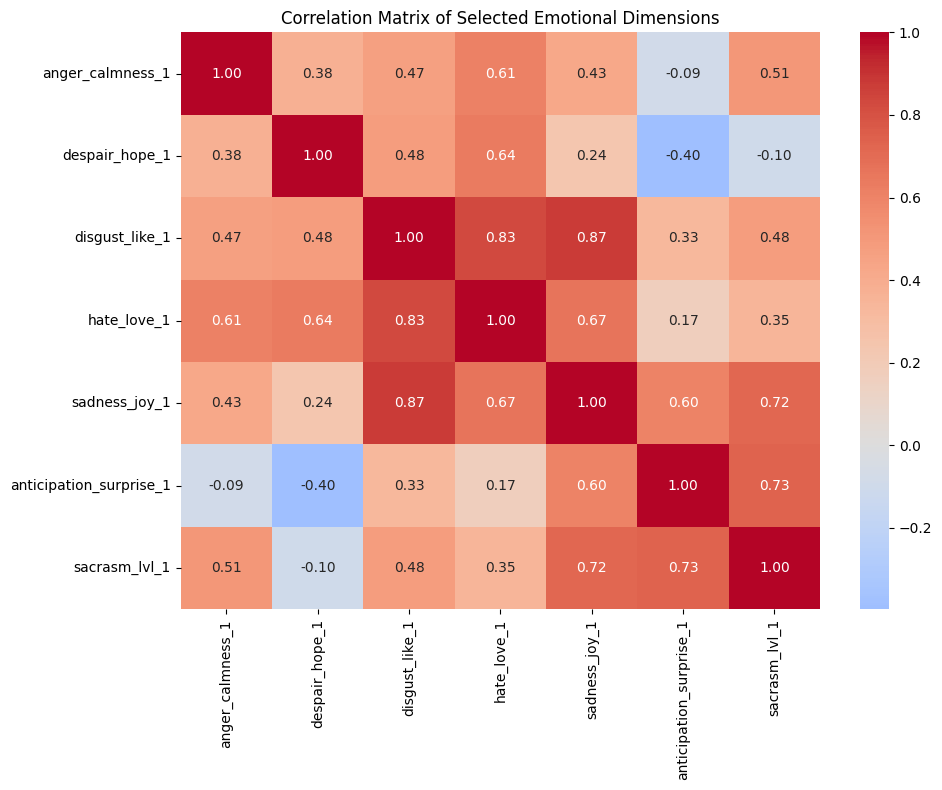

In [923]:
# Compute the correlation matrix
correlation_matrix = df_w_emotes_final_time[['anger_calmness_1','despair_hope_1','disgust_like_1',
                                             'hate_love_1','sadness_joy_1','anticipation_surprise_1','sacrasm_lvl_1']].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Matrix of Selected Emotional Dimensions")
plt.tight_layout()
plt.show()

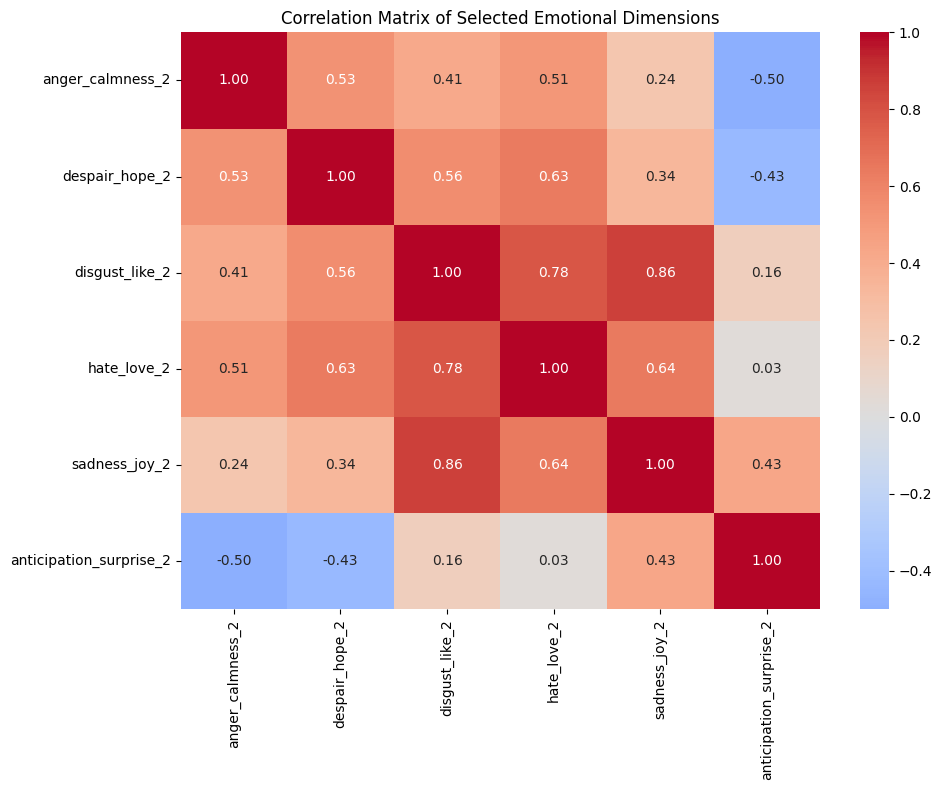

In [921]:
# Compute the correlation matrix
correlation_matrix = df_w_emotes_final_time[['anger_calmness_2','despair_hope_2','disgust_like_2',
                                             'hate_love_2','sadness_joy_2','anticipation_surprise_2']].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Matrix of Selected Emotional Dimensions")
plt.tight_layout()
plt.show()

### Annotators sentiment

In [931]:

# Read the entire text file
with open('/Users/rodionhorbunov/Downloads/4K_PGL_Major_Stockholm_2021_-_THE_GRAND_FINALS_part_001.txt', 'r', encoding='utf-8') as f:
    content = f.read()

# Split by double line breaks (i.e., paragraph separators)
paragraphs = [p.strip() for p in content.split('\n\n') if p.strip()]

# Create a DataFrame
df_text_1 = pd.DataFrame(paragraphs, columns=['text'])


In [929]:

# Read the entire text file
with open('/Users/rodionhorbunov/Downloads/4K_PGL_Major_Stockholm_2021_-_THE_GRAND_FINALS_part_002.txt', 'r', encoding='utf-8') as f:
    content = f.read()

# Split by double line breaks (i.e., paragraph separators)
paragraphs = [p.strip() for p in content.split('\n\n') if p.strip()]

# Create a DataFrame
df_text_2 = pd.DataFrame(paragraphs, columns=['text'])


In [933]:
df_text = pd.concat([df_text_1,df_text_2])
df_text = df_text.reset_index()

In [941]:
df_text.head()

,index,text
0,0,(instrumental music plays) (record scratches) ...
1,1,Smokes are gonna make a pass. Lining up and th...
2,2,The spot. Shush finding one. He's gonna get tr...
3,3,"If he unscoops, he's gonna know it. Nico, read..."
4,4,He's doing everything. He truly is the eternal...


In [943]:
pip install textblob

python(99334) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 4.3 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [945]:
from textblob import TextBlob


def get_sentiment_label(text):
    polarity = TextBlob(text).sentiment.polarity
    return 'good' if polarity >= 0 else 'bad'

# Apply it to your DataFrame
df_text['sentiment'] = df_text['text'].apply(get_sentiment_label)

print(df_text[['text', 'sentiment']].head())

                                                text sentiment
0  (instrumental music plays) (record scratches) ...      good
1  Smokes are gonna make a pass. Lining up and th...      good
2  The spot. Shush finding one. He's gonna get tr...      good
3  If he unscoops, he's gonna know it. Nico, read...      good
4  He's doing everything. He truly is the eternal...       bad


In [947]:
df_text['sentiment'].value_counts()

sentiment
good    1873
bad      300
Name: count, dtype: int64

In [957]:
for i in df_text[df_text['sentiment']=='bad']['text'][0:5]:
    print(i)

He's doing everything. He truly is the eternal MVP of this game. (rock music plays) Volacy needs something here to get Rifle back. Damone shows up, absolutely stunning play, shutting down Shush and Cadia. (rock music plays)
(triumphant music plays) Lord Boomich. (gunshots) He got beautiful shot. Ooh, there goes Hobbit. (gunshots) S1mple, in the meantime, finds another headshot. (gunshots) Ooh, and another one. Where does this guy do it? Shiro now the last one alive here for Gambit, hoping to be the hero. Oh, my God. That is disgusting.
(upbeat music) (fire crackling) Damn, man. This is getting mental warfare from NAVI, obliterating everyone, showing no quarter. (upbeat music) (fire crackling) Perhaps a trade coming in and indeed s1mple pulls out the Op. Now you have Aksel who's just gotten here to find a one, trying to keep Gambit alive into this series and holding on at the moment to the bomb site. Finds an awkward timing but 2erfecto is spot on. And s1mple has yet to even be put into